# QCNN-ID — A Quantum-Classical Hybrid Model for IoT Intrusion Detection

*Pedagogical reproduction walkthrough.*

**Paper.** Amara, Mnasri, Val. "QCNN-ID: A Quantum-Classical Hybrid Model for IoT Intrusion Detection". KES 2025. [hal-05080861](https://hal.science/hal-05080861v1).  
**Released code.** <https://github.com/MarwenPhd/QCNN_ID_on_MIot_dataset> — a single Jupyter notebook.  
**Dataset.** IoT Healthcare Security Dataset (Faisal Malik), <https://github.com/imfaisalmalik/IoT-Healthcare-Security-Dataset> (Kaggle mirror is gated).

---

### What you will see in this notebook

1. **Problem statement.** What the paper claims and what we test.
2. **Data pipeline.** Loading the three ICU CSVs, the preprocessing recipe, and what the PCA-reduced angle-encoded inputs actually look like.
3. **Three model families.** Side-by-side: the paper-text-described classical CNN and hybrid QCNN, and our MerLin photonic adaptation.
4. **Training demo.** A small deterministic comparison that runs in under ~5 minutes on CPU.
5. **MerLin walkthrough.** Computation space, detector model, and what the photonic layer is doing physically.
6. **Interpretation.** Which claims survive and which do not.

All heavy lifting lives in `lib/`; this notebook only orchestrates and visualises.

**Reductions for didactic speed.** The executable training cells keep a short demo: `subset_size=1000`, 8 PCA components/qubits, 40 epochs, one seed. The curated scientific comparison is loaded from the stable artifacts in `results/`, especially `current_notebook_1000_e40`, `intrusion_full_compare_10000_e15`, `intrusion_photonic_convergence_10000_e40`, and `intrusion_merlin_20000_e20_s3`. Set `PREFER_GPU = True` in the setup cell to use CUDA when available.

## 1. What the paper claims

The paper introduces a **hybrid quantum-classical CNN** for binary intrusion detection on network-flow features collected from medical-IoT devices. The pipeline is:

1. Z-score normalize the raw flow features.
2. Reduce to 8 principal components via PCA.
3. Min-max scale each component into $[0, \pi]$.
4. Encode the 8 scaled features into 8 qubits via $R_y$ and $R_x$ rotations (Eq. 4). ZZfeaturemap is used in practice.
5. Apply a parameterised variational ansatz $A(\theta)$ — rotations + entangling layers (Eq. 5). RealAmplitude is used here.
6. Read out the Pauli-$Z$ expectation on each qubit (Eq. 6) and feed the 8-vector into a small classical head for one binary logit.

Headline claims:

| ID | Claim | Where in paper |
|----|-------|----------------|
| C1 | QCNN matches CNN at ~99% accuracy | Fig. 3, Sec. 4.1 |
| C2 | QCNN uses fewer trainable parameters than CNN | Sec. 4.1 |
| C3 | QCNN reduces false negatives (22 vs 465) | Sec. 4.2, Fig. 4 |
| C4 | QCNN per-epoch wall-clock is higher (simulator cost) | Fig. 3(e) |


In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

PAPER_ROOT = Path('.').resolve()
if PAPER_ROOT.name != 'QCNN_ID':
    PAPER_ROOT = Path('papers/QCNN_ID').resolve()
sys.path.insert(0, str(PAPER_ROOT))

from lib.data import load_and_prepare
from lib.models import CNNClassifier, QCNNClassifier, PhotonicClassifier
from lib.training import train_and_evaluate_model

logging.basicConfig(level=logging.WARNING, format='%(levelname)s | %(message)s')
logger = logging.getLogger('notebook')
logger.setLevel(logging.INFO)

print('PAPER_ROOT     =', 'papers/QCNN_ID')
print('torch          =', torch.__version__)
print('cuda available =', torch.cuda.is_available())

PAPER_ROOT     = papers/QCNN_ID
torch          = 2.10.0+cu128
cuda available = True


## 2. The dataset and the preprocessing pipeline

The IoT Healthcare Security Dataset (a.k.a. ICU dataset) ships as three CSV files:

| File | Class | Label | Approx rows |
|------|-------|------:|------------:|
| `Attack.csv` | attack traffic | 1 | 80 k |
| `environmentMonitoring.csv` | environment-sensor traffic | 0 | 32 k |
| `patientMonitoring.csv` | patient-sensor traffic | 0 | 77 k |

Total: ~188 k rows, 50 raw feature columns (TCP, MQTT, IP fields), one binary `label` column. Class balance: ~42.5% attack / ~57.5% benign — this matches the paper's Sec. 3.1 statement exactly, and a 30%-test split (56,608 rows) reconciles the Fig. 4 confusion-matrix totals (`32,527 + 23,948 + 112 + 22 = 56,609`).

The author's notebook (cell 0) loads all three CSVs, concatenates them, shuffles with `random_state=42`, drops the textual `class` column, coerces every object column (hex flag strings, MAC traces, …) to numeric, and fills NaN with 0. Our `lib/data.py::load_and_prepare` does exactly that, then runs the StandardScaler → PCA(8) → min-max-to-$[0, \pi]$ pipeline described in the paper.

In [2]:
PREFER_GPU = False
device_name = "cuda:0" if PREFER_GPU and torch.cuda.is_available() else "cpu"

n_qubits = 8
n_rows = 1000  # QCNN duration is limited by simulator training.
device = torch.device(device_name)

demo_cfg = {
    'data_dir': 'QCNN_ID',
    'data_root': str(PAPER_ROOT.parents[1] / 'data'),
    'subset_size': n_rows,
    'test_size': 0.3,
    'n_components': n_qubits,
}

prepared = load_and_prepare(demo_cfg, seed=42)

print(f'device_name        : {device_name}')
print(f'n_qubits           : {n_qubits}')
print(f'train rows         : {prepared.n_train:>6d}')
print(f'test rows          : {prepared.n_test:>6d}')
print(f'full feature dim   : {prepared.n_features_full}')
print(f'PCA components     : {prepared.n_components}')
print(f'angle-scaled range : [{prepared.X_train_quantum.min():.3f}, {prepared.X_train_quantum.max():.3f}]   (target = [0, π]; π ≈ {np.pi:.3f})')
print(f'train class balance: {prepared.class_balance}')

device_name        : cpu
n_qubits           : 8
train rows         :    700
test rows          :    300
full feature dim   : 50
PCA components     : 8
angle-scaled range : [0.000, 3.142]   (target = [0, π]; π ≈ 3.142)
train class balance: {0: 0.5871428571428572, 1: 0.41285714285714287}


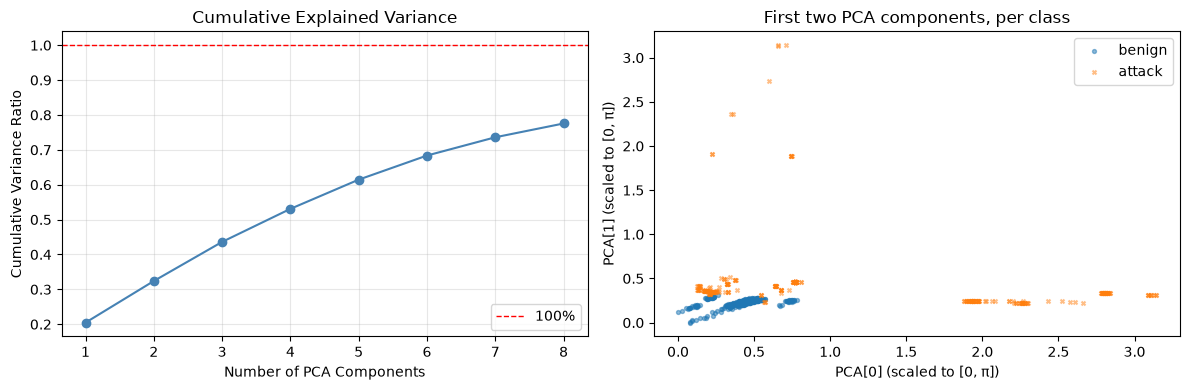

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Cumulative Explained Variance
axes[0].plot(range(1, len(prepared.cumulated_var) + 1), prepared.cumulated_var, marker='o', color='steelblue')
axes[0].axhline(y=1.0, color='red', lw=1, ls='--', label='100%')
axes[0].set_title('Cumulative Explained Variance')
axes[0].set_xlabel('Number of PCA Components')
axes[0].set_ylabel('Cumulative Variance Ratio')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. First two PCA components, per class
for label, marker in [(0, 'o'), (1, 'x')]:
    mask = prepared.y_train == label
    axes[1].scatter(prepared.X_train_quantum[mask, 0], prepared.X_train_quantum[mask, 1],
                    marker=marker, s=8, alpha=0.5,
                    label='benign' if label == 0 else 'attack')
axes[1].set_xlabel('PCA[0] (scaled to [0, π])')
axes[1].set_ylabel('PCA[1] (scaled to [0, π])')
axes[1].set_title('First two PCA components, per class')
axes[1].legend()

fig.tight_layout()
plt.show()

## 3. Three model families

All three classifiers take the same `n_components`-feature PCA vector and return one binary logit. They are compared on the same train/test split with the same loss (`BCEWithLogitsLoss`) and optimiser family (Adam).

| Name | Where it comes from | Input | Parameters |
|---|---|---|---|
| `CNNClassifier` | Paper text Sec. 3.3 (dense MLP: 128 → 64) | `n_components` PCA features | thousands |
| `QCNNClassifier` | Paper-text gate-model hybrid + authors code | `n_components` PCA features, $[0, \pi]$ | tens |
| `PhotonicClassifier` | Our MerLin photonic adaptation | `n_components` PCA features, $[0, \pi]$ | tens |


In [4]:
# Quick smoke check: every model accepts a (B, n_components) tensor and emits (B, 1) logits.
torch.manual_seed(42)
B = 3
x_pca = torch.randn(B, n_qubits, device=device)
x_q = torch.rand(B, n_qubits, device=device) * np.pi

n_modes = n_qubits
n_photons = n_modes // 2
print("Quantum parameters  :")
print(f'n_qubits           : {n_qubits}')
print(f'n_modes            : {n_qubits}')
print(f'n_photons          : {n_photons}')

demo = [
    ('CNNClassifier', CNNClassifier(input_dim=n_qubits, device=device), x_pca),
    ('QCNNClassifier', QCNNClassifier(n_qubits=n_qubits, device=device), x_q),
    ('PhotonicClassifier', PhotonicClassifier(n_modes=n_modes, n_photons=n_photons, device=device), x_q),
]
for name, model, x in demo:
    out = model(x)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name:42s} out={tuple(out.shape)}  params={n_params}')

Quantum parameters  :
n_qubits           : 8
n_modes            : 8
n_photons          : 4
CNNClassifier                              out=(3, 1)  params=9473
QCNNClassifier                             out=(3, 1)  params=25
PhotonicClassifier                         out=(3, 1)  params=71


### 3.1 What's inside the `QCNNClassifier` model?

* Pennylane implementation aligned with the author's code using qiskit.
* `ZZFeatureMap`-style angle encoding of the inputs (phase rotations and CNOT entanglers).
* RealAmplitudes ansatz followed by Pauli-Z expectation measurements — Eq. 6.
* A trainable `nn.Linear(n_qubits, 1)` head implements `logit(x)=W·E(x)+B` and trains with `BCEWithLogitsLoss`.

## 4. Train all three models on the same split

We share `lib/training.py::train_and_evaluate_model` across model families so the comparison is apples-to-apples:

* Same optimiser (Adam), same `BCEWithLogitsLoss`, same batch size, same epochs.
* Quantum models use a slightly larger learning rate to compensate for the smaller parameter count.
* Each call reseeds PyTorch so the only stochasticity left is the model's own initialisation.

In [5]:
EPOCHS = 40
BATCH = 128
LR_CNN = 1e-3
LR_QCNN = 0.01
LR_PHOTONIC = 0.05

specs = [
    ('cnn_classifier', lambda: CNNClassifier(input_dim=n_qubits, device=device),
                       prepared.X_train_classical, prepared.X_test_classical, LR_CNN),
    ('photonic_classifier', lambda: PhotonicClassifier(n_modes=n_qubits, n_photons=n_qubits//2, device=device),
                       prepared.X_train_quantum,    prepared.X_test_quantum,    LR_PHOTONIC),
    ('qcnn_classifier', lambda: QCNNClassifier(n_qubits=n_qubits, reps=1, device=device),
                       prepared.X_train_quantum,    prepared.X_test_quantum,    LR_QCNN),
]

histories = []
for name, model_factory, xtr, xte, lr in specs:
    torch.manual_seed(42)
    np.random.seed(42)
    model = model_factory()
    h = train_and_evaluate_model(
        name, model, xtr, prepared.y_train, xte, prepared.y_test,
        epochs=EPOCHS, batch_size=BATCH, lr=lr, device=device, logger=logger,
    )
    histories.append(h)
    print(f'{name:18s}  acc={h.final_accuracy:.4f}  prec={h.final_precision:.4f}  '
          f'rec={h.final_recall:.4f}  params={h.param_count:>6d}  time={h.train_time_s:.1f}s')

INFO | [cnn_classifier] epoch 1/40 | train_loss=0.6877 | test_loss=0.6271 | acc=0.8300 | prec=0.8877 | rec=0.7944 | t=0.01s
INFO | [cnn_classifier] epoch 2/40 | train_loss=0.6064 | test_loss=0.5474 | acc=0.9867 | prec=0.9889 | rec=0.9839 | t=0.01s
INFO | [cnn_classifier] epoch 3/40 | train_loss=0.5307 | test_loss=0.4614 | acc=0.9867 | prec=0.9889 | rec=0.9839 | t=0.01s
INFO | [cnn_classifier] epoch 4/40 | train_loss=0.4410 | test_loss=0.3680 | acc=0.9867 | prec=0.9889 | rec=0.9839 | t=0.01s
INFO | [cnn_classifier] epoch 5/40 | train_loss=0.3523 | test_loss=0.2787 | acc=0.9867 | prec=0.9889 | rec=0.9839 | t=0.01s
INFO | [cnn_classifier] epoch 6/40 | train_loss=0.2604 | test_loss=0.2022 | acc=0.9833 | prec=0.9862 | rec=0.9798 | t=0.01s
INFO | [cnn_classifier] epoch 7/40 | train_loss=0.1947 | test_loss=0.1425 | acc=0.9833 | prec=0.9862 | rec=0.9798 | t=0.01s
INFO | [cnn_classifier] epoch 8/40 | train_loss=0.1378 | test_loss=0.1001 | acc=0.9833 | prec=0.9862 | rec=0.9798 | t=0.01s
INFO | [

cnn_classifier      acc=0.9967  prec=0.9972  rec=0.9960  params=  9473  time=0.6s


INFO | [photonic_classifier] epoch 7/40 | train_loss=0.5112 | test_loss=0.4977 | acc=0.8600 | prec=0.9037 | rec=0.8306 | t=0.03s
INFO | [photonic_classifier] epoch 8/40 | train_loss=0.4906 | test_loss=0.4779 | acc=0.8600 | prec=0.9037 | rec=0.8306 | t=0.02s
INFO | [photonic_classifier] epoch 9/40 | train_loss=0.4701 | test_loss=0.4583 | acc=0.8667 | prec=0.9074 | rec=0.8387 | t=0.03s
INFO | [photonic_classifier] epoch 10/40 | train_loss=0.4511 | test_loss=0.4405 | acc=0.8800 | prec=0.9151 | rec=0.8548 | t=0.03s
INFO | [photonic_classifier] epoch 11/40 | train_loss=0.4334 | test_loss=0.4239 | acc=0.9533 | prec=0.9632 | rec=0.9435 | t=0.03s
INFO | [photonic_classifier] epoch 12/40 | train_loss=0.4173 | test_loss=0.4084 | acc=0.9533 | prec=0.9632 | rec=0.9435 | t=0.01s
INFO | [photonic_classifier] epoch 13/40 | train_loss=0.4021 | test_loss=0.3935 | acc=0.9533 | prec=0.9632 | rec=0.9435 | t=0.03s
INFO | [photonic_classifier] epoch 14/40 | train_loss=0.3875 | test_loss=0.3798 | acc=0.9533 

photonic_classifier  acc=0.9800  prec=0.9835  rec=0.9758  params=    71  time=1.3s


INFO | [qcnn_classifier] epoch 1/40 | train_loss=0.6793 | test_loss=0.6728 | acc=0.5867 | prec=0.2933 | rec=0.5000 | t=3.03s
INFO | [qcnn_classifier] epoch 2/40 | train_loss=0.6681 | test_loss=0.6621 | acc=0.5867 | prec=0.2933 | rec=0.5000 | t=3.10s
INFO | [qcnn_classifier] epoch 3/40 | train_loss=0.6576 | test_loss=0.6519 | acc=0.5867 | prec=0.2933 | rec=0.5000 | t=3.06s
INFO | [qcnn_classifier] epoch 4/40 | train_loss=0.6468 | test_loss=0.6417 | acc=0.5867 | prec=0.2933 | rec=0.5000 | t=3.10s
INFO | [qcnn_classifier] epoch 5/40 | train_loss=0.6358 | test_loss=0.6308 | acc=0.5867 | prec=0.2933 | rec=0.5000 | t=3.07s
INFO | [qcnn_classifier] epoch 6/40 | train_loss=0.6244 | test_loss=0.6191 | acc=0.6067 | prec=0.7993 | rec=0.5242 | t=3.08s
INFO | [qcnn_classifier] epoch 7/40 | train_loss=0.6119 | test_loss=0.6066 | acc=0.6200 | prec=0.8034 | rec=0.5403 | t=3.23s
INFO | [qcnn_classifier] epoch 8/40 | train_loss=0.5987 | test_loss=0.5935 | acc=0.6233 | prec=0.8045 | rec=0.5444 | t=3.07s


qcnn_classifier     acc=0.9367  prec=0.9422  rec=0.9282  params=    25  time=185.3s


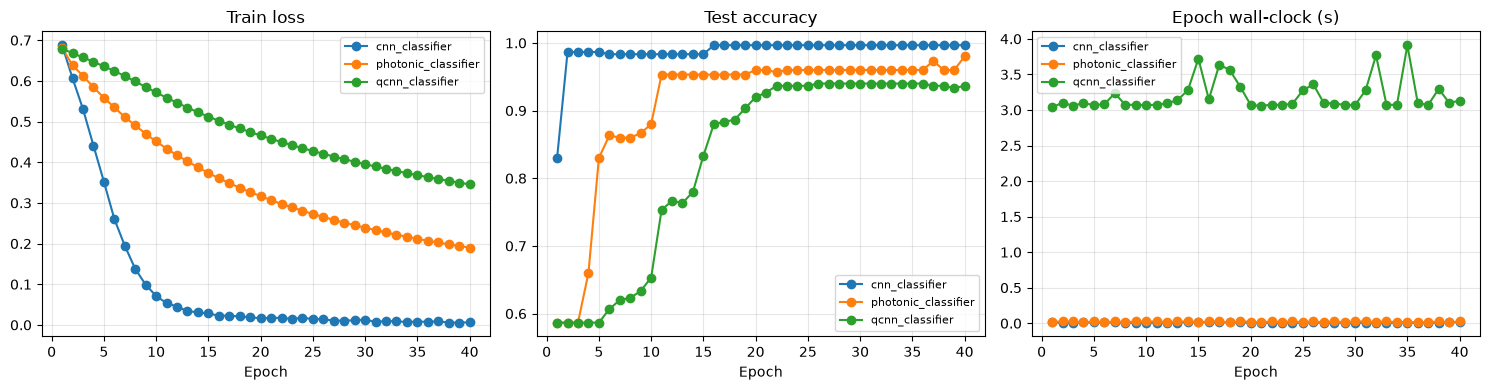

In [6]:
# Loss / accuracy / wall-clock curves across the three model families.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes,
                           ['loss', 'accuracy', 'time_s'],
                           ['Train loss', 'Test accuracy', 'Epoch wall-clock (s)']):
    for h in histories:
        ax.plot(range(1, len(h.epochs) + 1),
                [getattr(e, key) for e in h.epochs], marker='o', label=h.name)
    ax.set_xlabel('Epoch'); ax.set_title(title); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

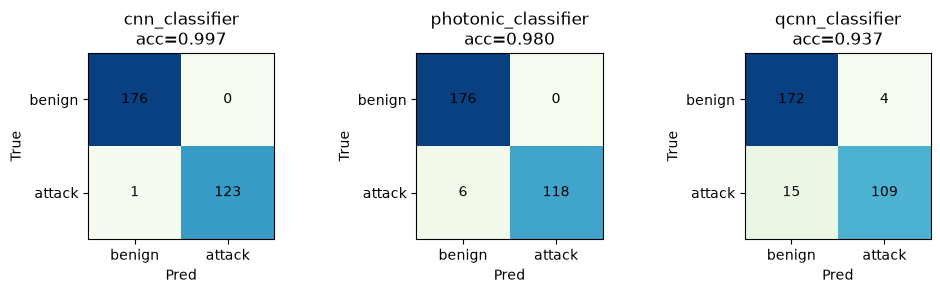

In [7]:
# Confusion matrices side-by-side (1 = attack, 0 = benign).
fig, axes = plt.subplots(1, len(histories), figsize=(10, 3))
for ax, h in zip(axes, histories):
    cm = np.array(h.confusion_matrix)
    #ax.imshow(cm, cmap='YlGnBu')
    ax.imshow(cm, cmap='GnBu')
    ax.set_title(f'{h.name}\nacc={h.final_accuracy:.3f}')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['benign', 'attack']); ax.set_yticklabels(['benign', 'attack'])
    ax.set_xlabel('Pred'); ax.set_ylabel('True')
fig.tight_layout()
plt.show()

## 5. MerLin photonic walkthrough

The `PhotonicClassifier` is the photonic adaptation: instead of running an 8-qubit gate-model circuit, we run an 8-mode linear-optical circuit with 4 photons. The Bell-state-like input `[1, 0, 1, 0, 1, 0, 1, 0]` spreads the photons across the modes.

Each PCA feature is encoded as a **phase shift** on its mode, the photons interfere through fixed random interferometers used as a reservoir, and the trainable head consumes the probability distribution over all $\binom{8}{4} = 70$ photon-arrival patterns under **UNBUNCHED** computation space (threshold detection — what a real photonic chip's detectors see).

In [8]:
print("For 8 input, i.e. 8 qubits :")
photonic_model = PhotonicClassifier(n_modes=8, n_photons=4, device=device)
print(f'output_size (= C(8, 4))    : {photonic_model.output_size}')

x_demo = torch.rand(1, 8).to(device) * np.pi
probs = photonic_model.qlayer(x_demo)
print(f'Σ probs (should be ≈ 1)    : {float(probs.sum()):.6f}')
print(f'most likely Fock outcome   : {int(probs.argmax())}')
print(f'binary logit (Linear(70 → 1)): {photonic_model.head(probs).cpu().detach().numpy().ravel()}')

For 8 input, i.e. 8 qubits :
output_size (= C(8, 4))    : 70
Σ probs (should be ≈ 1)    : 1.000000
most likely Fock outcome   : 40
binary logit (Linear(70 → 1)): [-0.01544588]


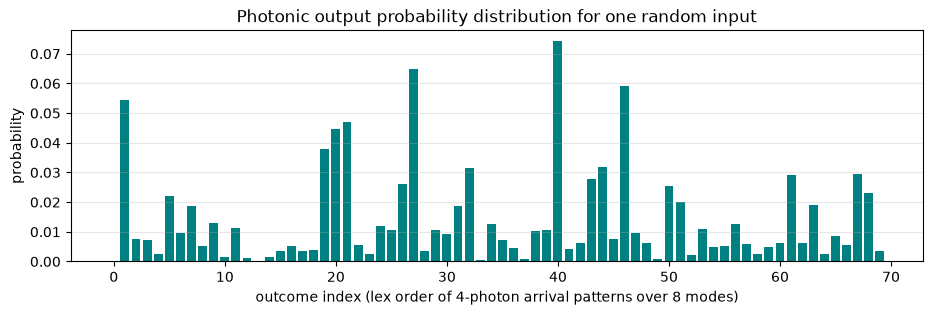

In [9]:
# What does the 70-bin output distribution look like?
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(np.arange(photonic_model.output_size), probs.cpu().detach().numpy().ravel(), color='teal')
ax.set_xlabel('outcome index (lex order of 4-photon arrival patterns over 8 modes)')
ax.set_ylabel('probability')
ax.set_title('Photonic output probability distribution for one random input')
ax.grid(axis='y', alpha=0.3)
plt.show()

### Hardware-aware summary (this configuration)

| Field | Value |
|---|---|
| Computation space | `UNBUNCHED` |
| Detector model | threshold |
| Photon number | 4 |
| Number of modes | 8 |
| Input state | `[1, 0, 1, 0, 1, 0, 1, 0]` |
| Encoding | angle (one phase per mode); data already scaled to $[0, \pi]$ |
| Measurement strategy | `MeasurementStrategy.PROBABILITIES` |
| Postselection | none |
| Simulator | SLOS MerLin, CPU simulator, analytic (`shots = 0`) |
| Output size | `C(8, 4) = 70`, projected to one binary logit via `nn.Linear(70, 1)` |

## 6. Interpretation and claim verdicts

The executable cells above are intentionally notebook-sized. The current notebook run is mirrored by `results/current_notebook_1000_e40/` (`subset_size=1000`, PCA-8, `epochs=40`, `ansatz_reps=1`, `seed=42`, CPU). Longer curated artifacts are stored in `results/`.

Notebook-sized result:

| Model | Accuracy | Macro precision | Macro recall | ROC-AUC | Params | Runner train time | False negatives |
|---|---:|---:|---:|---:|---:|---:|---:|
| `CNNClassifier` | **0.9967** | **0.9972** | **0.9960** | **0.9998** | 9,473 | 0.89 s | **1** |
| `PhotonicClassifier` | 0.9800 | 0.9835 | 0.9758 | 0.9962 | 71 | 0.66 s | 6 |
| `QCNNClassifier` | 0.9367 | 0.9422 | 0.9282 | 0.9813 | **25** | 198.10 s | 15 |

Confusion matrices use rows=true labels `[benign, attack]` and columns=predictions `[benign, attack]`: CNN `[[176, 0], [1, 123]]`, Photonic `[[176, 0], [6, 118]]`, QCNN `[[172, 4], [15, 109]]`.

Main all-model comparison: `results/intrusion_full_compare_10000_e15/` (`subset_size=10000`, PCA-8, `epochs=15`, `ansatz_reps=2`, `lr_qcnn=0.02`, `seed=42`, CPU). CNN reaches 99.83% accuracy with 4 false negatives; Photonic reaches 98.53% with 44 false negatives; QCNN reaches 97.33% with 35 false negatives.

Photonic convergence diagnostic: `results/intrusion_photonic_convergence_10000_e40/` shows that the photonic predictions stabilize by about epoch 18 at 98.57% accuracy. 

Claim verdicts:

| Claim | Paper statement | Verdict in local runs | Evidence |
|---|---|---|---|
| C1 | QCNN matches CNN at about 99% accuracy | **Not reproduced.** | QCNN reaches 97.33% on the 10k all-model run and 93.67% in this notebook e40 run; CNN reaches 99.83% and 99.67%, respectively. |
| C2 | QCNN uses fewer trainable parameters | **Confirmed structurally.** | QCNN has 25 trainable params at `ansatz_reps=1` and 33 at `ansatz_reps=2`, versus 9,473 for CNN. |
| C3 | QCNN reduces false negatives | **Not reproduced.** | 10k all-model run: CNN 4 FN vs QCNN 35 FN. Notebook e40: CNN 1 FN vs QCNN 15 FN. |
| C4 | QCNN has higher simulator cost and total training time | **Confirmed.** | Runner artifacts report total training time: notebook e40 QCNN 198.10 s vs CNN 0.89 s; 10k all-model QCNN 1427.61 s vs CNN 1.30 s. Per-epoch logs show the same gap. |

**MerLin model result.** The MerLin photonic adaptation turns out to be the strongest quantum-side local baseline in these artifacts.

* **Accuracy.** On the 20k/3-seed run it reaches **98.87% ± 0.34% accuracy**, with 201 false negatives and only 3 false positives across the aggregated 18k test examples. In the 10k all-model comparison it reaches **98.53%**, above the gate-model QCNN at **97.33%**.
* **Speed.** In that same 10k all-model run, MerLin photonic training takes **3.46 s**, while the gate-model QCNN takes **1427.61 s** in the local simulator.
* **Parameter count.** MerLin uses **71 trainable parameters**: more than the QCNN (**33**), but far fewer than the CNN (**9,473**).
